In [5]:
# 訓練データとテストデータの画像を読み込む
# （サイズは縦横224pxにリサイズする）
import tensorflow as tf

train_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    "train",
    image_size=(224, 224),
    label_mode="binary",
    batch_size=32,
    shuffle=True
)

test_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    "test",
    image_size=(224, 224),
    label_mode="binary",
    batch_size=32,
    shuffle=False
)

Found 300 files belonging to 2 classes.
Found 100 files belonging to 2 classes.


In [6]:
list(train_dataset.as_numpy_iterator())[0]

(array([[[[165.      , 162.      , 143.      ],
          [164.90178 , 161.91072 , 142.88393 ],
          [150.16965 , 148.51785 , 125.47321 ],
          ...,
          [ 79.35936 ,  76.988846,  34.674103],
          [ 77.015594,  77.99332 ,  34.004456],
          [ 77.      ,  78.      ,  34.      ]],
 
         [[164.97768 , 161.9866  , 142.98885 ],
          [164.8795  , 161.89737 , 142.8728  ],
          [150.15335 , 148.51048 , 125.46807 ],
          ...,
          [ 79.39003 ,  77.0292  ,  34.720398],
          [ 77.03132 ,  78.017975,  34.035805],
          [ 77.015625,  78.02455 ,  34.03125 ]],
 
         [[161.62947 , 159.97768 , 141.31473 ],
          [161.53726 , 159.89441 , 141.20468 ],
          [147.70795 , 147.40437 , 124.696785],
          ...,
          [ 83.99082 ,  83.08213 ,  41.66494 ],
          [ 79.389984,  81.716675,  38.738224],
          [ 79.359375,  81.70759 ,  38.71875 ]],
 
         ...,
 
         [[158.3482  , 178.3482  , 125.348206],
          [158.350

In [7]:
class_names = train_dataset.class_names
class_names

['cat', 'dog']

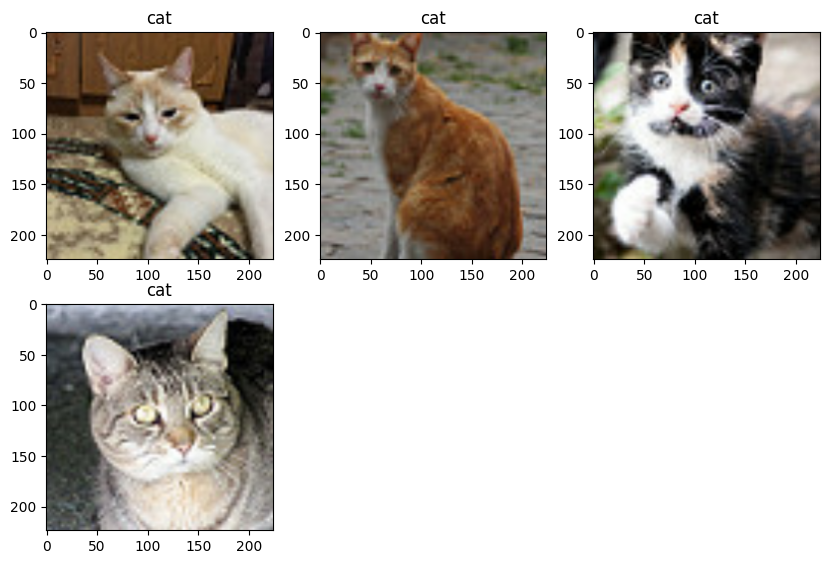

In [8]:
# 訓練データの一部を表示して確認
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))

for images, labels in train_dataset.take(1):
    for i in range(4):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i].numpy().astype("uint8")[0]])

In [9]:
# 画像の水増しをする関数の定義
def flip_left_right(image, label):   # 左右反転
    image = tf.image.flip_left_right(image)
    return image, label

def flip_up_down(image, label):      # 上下反転
    image = tf.image.flip_up_down(image)
    return image, label

def rot90(image, label):             # 反時計回りに90度回転
    image = tf.image.rot90(image)
    return image, label

def rot180(image, label):            # 反時計回りに180度回転
    image = tf.image.rot90(image, k=2)
    return image, label

def rot270(image, label):            # 反時計回りに270度回転
    image = tf.image.rot90(image, k=3)
    return image, label

In [10]:
# 画像の水増し処理の実行
train_dataset_lr     = train_dataset.map(flip_left_right)
train_dataset_ud     = train_dataset.map(flip_up_down)
train_dataset_rot90  = train_dataset.map(rot90)
train_dataset_rot180 = train_dataset.map(rot180)
train_dataset_rot270 = train_dataset.map(rot270)

In [11]:
# データをシャッフルする  32はバッチさいずと同じにするので
train_dataset = train_dataset.shuffle(32)

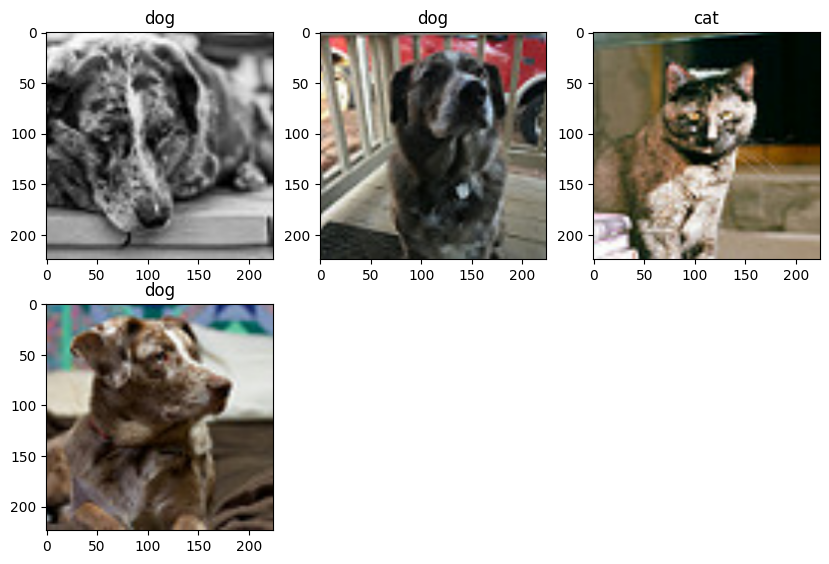

In [12]:
# 訓練データの一部を表示して確認
plt.figure(figsize=(10, 10))

for images, labels in train_dataset.take(1):
    for i in range(4):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i].numpy().astype("uint8")[0]])

In [13]:
# MobileNetV2モデルを作成する
input_layer = tf.keras.Input(shape=(224, 224, 3))   # 入力層
l_layer = tf.keras.applications.mobilenet_v2.preprocess_input(input_layer)   # 前処理（正規化）をする層

base_model = tf.keras.applications.mobilenet_v2.MobileNetV2(
    input_shape=(224, 224, 3),
    input_tensor=l_layer,
    include_top=False,
    weights="imagenet",
    pooling='avg'
)
base_model.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [14]:
# Dense層を追加する
output_layer = tf.keras.layers.Dense(1, activation='sigmoid')

In [15]:
# base_modelに先ほどのDense層を追加したモデルを作成する
model = tf.keras.Sequential([
    base_model,
    output_layer
])

In [16]:
# modelをcompileする
model.compile(optimizer="adam",
              loss='binary_crossentropy',
              metrics=["accuracy"])

In [17]:
# modelに学習させる
model.fit(train_dataset, epochs=20)

Epoch 1/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 141ms/step - accuracy: 0.5160 - loss: 0.7297
Epoch 2/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 137ms/step - accuracy: 0.9103 - loss: 0.3362
Epoch 3/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 134ms/step - accuracy: 0.9599 - loss: 0.2024
Epoch 4/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 134ms/step - accuracy: 0.9739 - loss: 0.1351
Epoch 5/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 133ms/step - accuracy: 0.9920 - loss: 0.0870
Epoch 6/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 132ms/step - accuracy: 0.9944 - loss: 0.0860
Epoch 7/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 132ms/step - accuracy: 0.9973 - loss: 0.0554
Epoch 8/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 133ms/step - accuracy: 0.9886 - loss: 0.0677
Epoch 9/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 133ms/step - accuracy: 0.9941 - loss: 0.0627
Epoch 10/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 134ms/step - accuracy: 0.9982 - loss: 0.0454
Epoch 11/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 133ms/step - accuracy: 0.9972 - loss: 0.0412
Epoch 12/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 136ms/step

In [18]:
pred_data = model.predict(test_dataset)

4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 295ms/step


In [19]:
pred_data

array([[1.1702033e-03],
       [1.4390118e-02],
       [1.4300063e-03],
       [6.7482534e-04],
       [1.8911976e-03],
       [2.1340377e-03],
       [1.0241801e-03],
       [4.9844419e-04],
       [3.4846128e-03],
       [6.8189204e-04],
       [1.8473723e-03],
       [1.0509617e-02],
       [1.9001993e-03],
       [3.2705704e-03],
       [7.1894599e-04],
       [2.4740194e-04],
       [8.7917037e-04],
       [1.1621104e-03],
       [3.0616261e-03],
       [1.7176095e-02],
       [9.7711943e-02],
       [8.8495396e-02],
       [4.4646584e-03],
       [1.0130078e-02],
       [3.0649602e-01],
       [1.0513083e-02],
       [1.2801639e-02],
       [4.7301962e-03],
       [1.3551193e-02],
       [1.2211336e-03],
       [2.3260929e-03],
       [3.8665897e-01],
       [2.5961208e-03],
       [2.2158993e-03],
       [2.6073214e-02],
       [9.6597505e-01],
       [2.6926791e-02],
       [7.8337695e-03],
       [1.6452117e-02],
       [2.0585774e-02],
       [5.4215989e-04],
       [2.710596

In [20]:
model.evaluate(test_dataset)

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 108ms/step - accuracy: 0.9908 - loss: 0.0574


[0.05615983530879021, 0.9900000095367432]